

### What is an LSTM?

LSTM stands for Long Short-Term Memory. It is a type of recurrent neural network (RNN) architecture that is well-suited for learning from sequences of data, such as time series, speech, and text. LSTMs are designed to overcome the limitations of traditional RNNs, particularly the problem of vanishing and exploding gradients, which makes it difficult for RNNs to learn long-term dependencies.

### Key Components of LSTM

An LSTM network consists of a series of repeating modules, each containing several interacting layers. The key components of an LSTM cell are:

1. **Cell State (Ct)**: This is the memory of the network, which carries information across different time steps. It allows the network to remember or forget information over long periods.

2. **Hidden State (ht)**: This is the output of the LSTM cell at a particular time step, which is passed to the next cell.

3. **Gates**: LSTMs have three types of gates that regulate the flow of information:
   - **Forget Gate (ft)**: Decides what information to discard from the cell state.
   - **Input Gate (it)**: Decides which new information to add to the cell state.
   - **Output Gate (ot)**: Decides what part of the cell state to output as the hidden state.

### How LSTM Works

At each time step, the LSTM cell performs the following operations:

1. **Forget Gate**: Determines what information from the previous cell state should be forgotten.
   ```python
   ft = sigmoid(Wf * [ht-1, xt] + bf)
   ```

2. **Input Gate**: Determines what new information should be added to the cell state.
   ```python
   it = sigmoid(Wi * [ht-1, xt] + bi)
   ```

3. **Candidate Cell State**: Creates a vector of new candidate values that could be added to the cell state.
   ```python
   ~Ct = tanh(WC * [ht-1, xt] + bC)
   ```

4. **Update Cell State**: Updates the cell state by combining the old cell state and the candidate cell state.
   ```python
   Ct = ft * Ct-1 + it * ~Ct
   ```

5. **Output Gate**: Determines the output of the LSTM cell.
   ```python
   ot = sigmoid(Wo * [ht-1, xt] + bo)
   ht = ot * tanh(Ct)
   ```

### Summary

LSTMs are powerful because they can maintain and update a memory cell over long sequences, making them effective for tasks where context and sequential information are important. They are widely used in applications such as language modeling, machine translation, and time series forecasting.

If you have any specific questions or need further details, feel free to ask!

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 0, Loss: 1.0487157288673916
Epoch 100, Loss: 0.0017655124862147886
Epoch 200, Loss: 0.0013449042424986146
Epoch 300, Loss: 0.0015620548859077489
Epoch 400, Loss: 0.0004743959547090881
Epoch 500, Loss: 0.00103716584307449
Epoch 600, Loss: 0.0006474120762167601
Epoch 700, Loss: 0.0004232115880224541
Epoch 800, Loss: 0.0003632634259901124
Epoch 900, Loss: 0.0004912881589740437


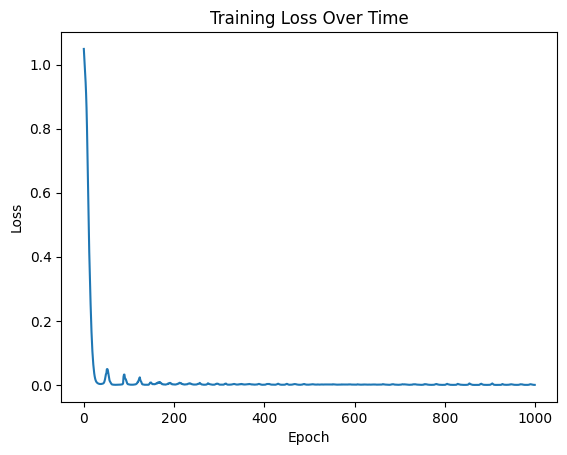

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input_seq):
        h0 = torch.zeros(1, input_seq.size(1), self.hidden_size)
        c0 = torch.zeros(1, input_seq.size(1), self.hidden_size)
        lstm_out, _ = self.lstm(input_seq, (h0, c0))
        output = self.fc(lstm_out[-1])
        return output

# Hyperparameters
input_size = 10
hidden_size = 20
output_size = 1
learning_rate = 0.001
epochs = 1000

# Initialize the LSTM
lstm = SimpleLSTM(input_size, hidden_size, output_size)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm.parameters(), lr=learning_rate)

# Generate dummy data
data = [torch.randn(5, 1, input_size) for _ in range(100)]
targets = [torch.randn(1, output_size) for _ in range(100)]

# Training loop
losses = []
for epoch in range(epochs):
    total_loss = 0
    for i in range(len(data)):
        input_seq = data[i]
        target = targets[i]

        optimizer.zero_grad()
        output = lstm(input_seq)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(data)
    losses.append(avg_loss)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss}')

# Plot the training loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()